# Manim  Community Edition

Uma biblioteca feita em python por Grant Sanderson, do canal 3Blue1Brown em 2015 para criação de seus vídeos, como um projeto pessoal.

Em 2020 a comunidade decidiu fazer um fork da versão pessoal do Grant e criaram o **ManimCE**

# Instalação do Manim

In [ ]:
!sudo apt update
!sudo apt install libcairo2-dev ffmpeg \
    texlive texlive-latex-extra texlive-fonts-extra \
    texlive-latex-recommended texlive-science \
    tipa libpango1.0-dev
!pip install manim
!pip install IPython==8.21.0

## Importando a biblioteca e seus elementos

In [ ]:
from manim import *

config.media_embed = True

# Conceitos Básicos

**Cena:** A cena é onde a animação irá acontecer. Ela é quem adiciona os objetos, liga as animações, pausa, adiciona legendas, etc.

**Objetos:** Para compor uma cena, adicionamos objetos a ela. Existem diferentes tipos de objetos, como formas geométricas, textos, funções, etc.

**Animações:** Para exibir os objetos que desejamos na tela, precisamos animar sua construção na cena. Para isso a duas principais funções para criar animações simples, o "Create" e "Transform".

**CLI:** O Manim fornece uma ferramenta de linha de comando para renderizarmos nosso vídeos, sendo este um elemento fundamental para visualização da cena.

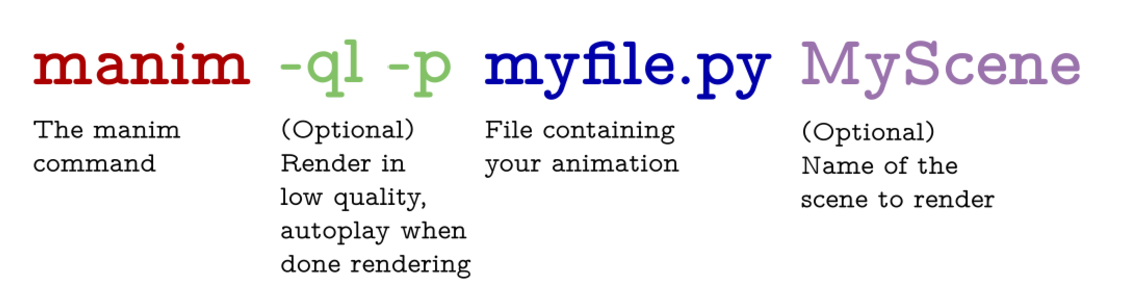

**Criando algumas formas geométricas**

In [ ]:
%%manim -pqh SquareToCircleToTriangle

class SquareToCircleToTriangle(Scene):
   def construct(self):
      square = Square().to_corner(UL)
      circulo = Circle().to_edge(DOWN)
      triangulo = Triangle()

      self.play(Create(square))
      self.play(square.animate.rotate(PI), runtime=2)
      self.play(square.animate.set_fill(RED, opacity=0.5), runtime=2)
      self.play(Transform(square, circulo), runtime=3)
      self.play(Create(triangulo))
      self.wait(3)

In [ ]:
%%manim -pql Texto

class Texto(Scene):
  def construct(self):
    texto = Text("Descmat")
    square = Square()
    circulo = Circle()
    label = Text("Isto é um quadrado")
    self.add(square, label)

    self.play(Write(label))

    self.play(Rotate(square, run_time=2))

    texto.to_corner(UR)
    self.play(Write(texto))
    self.play(Transform(texto, circulo), run_time=5)
    self.play(FadeOut(circulo))

# Posicionando objetos

# Utilizando o método .animate

# Funções matemáticas

In [ ]:
%%manim -pql Graficos

class Graficos(Scene):
  def construct(self):
    eixos = Axes(x_range=[-4, 4], y_range=[-4,4], axis_config={"color": WHITE, "include_numbers": True})

    graph = eixos.plot(lambda x: x**2, color=BLUE)
    label = eixos.get_graph_label(graph, label="x^2")

    self.play(Create(eixos), Create(graph), Write(label), run_time=3)
    self.wait(5)

In [ ]:
%%manim -pql Seno

class Seno(Scene):
  def construct(self):
    eixos = Axes(x_range=[-PI,PI], y_range=[-2, 2])
    graph = eixos.plot(lambda x: np.sin(x), color=YELLOW)
    label = eixos.get_graph_label(graph, label="sin(x)")
    label.to_corner(UR)

    self.play(Create(eixos), Create(graph), Write(label), run_time=3)

In [ ]:
%%manim -pql Paraboloid3D

from manim import *

def surfaceParaboloid(u, v):
    x = u
    y = v
    z = x**2 + y**2
    return np.array([x, y, z])

class Paraboloid3D(ThreeDScene):
    def construct(self):
        # Configurando os eixos
        axes = ThreeDAxes(
            x_range=[-4, 4, 1],
            y_range=[-4, 4, 1],
            z_range=[-1, 10, 1]
        )

        # Superfície: z = x² + y²
        surface = Surface(
            lambda u, v: axes.c2p(u, v, u**2 + v**2),
            u_range=[-2, 2],
            v_range=[-2, 2],
            resolution=(10, 10),
            color=BLUE,
            fill_opacity=0.7,
        )

        surface2 = Surface(
            lambda u, v: axes.c2p(u, v, 2),
            u_range=[-3,3],
            v_range=[-3, 3],
            resolution=(10, 10),
            color=BLUE,
            fill_opacity=0.7,
        )

        # Alterando as cores dos eixos
        axes.x_axis.set_color(RED)
        axes.y_axis.set_color(GREEN)
        axes.z_axis.set_color(BLUE)

        # Adicionando etiquetas coloridas
        x_label = axes.get_x_axis_label("x").set_color(RED)
        y_label = axes.get_y_axis_label("y").set_color(GREEN)
        z_label = axes.get_z_axis_label("z").set_color(BLUE)

        x_label.shift(UP * 0.5)  # Move a etiqueta x um pouco para cima
        y_label.shift(UP * 0.5)  # Move a etiqueta y um pouco para cima
        z_label.shift(UP * 0.5)  # Move a etiqueta z um pouco para cima

        # Adicionando a equação
        equation = MathTex("z = x^2 + y^2")
        equation.scale(0.7)  # Ajusta o tamanho do texto
        equation.to_corner(UL)  # Posiciona no canto superior esquerdo

        # Adicionando gradiente na superfície
        surface.set_color_by_gradient(RED, ORANGE, YELLOW)

        # Configurando a câmera
        self.set_camera_orientation(phi=40 * DEGREES, theta=0 * DEGREES)
        self.move_camera(focus_on=ORIGIN, zoom=0.7)

        # Animações
        self.add_fixed_in_frame_mobjects(equation)  # Fixa o texto no frame
        self.play(Create(axes), run_time=3)
        self.play(Create(surface), run_time=5)
        self.play(Create(surface2), run_time=5)
        self.play(Write(equation))
        self.play(Write(x_label), Write(y_label), Write(z_label), run_time=2)
        self.begin_ambient_camera_rotation(rate=0.1)  # Roda a câmera continuamente
        self.wait(5)
        self.stop_ambient_camera_rotation()
